<a href="https://colab.research.google.com/github/elliottgruzin/tutorials/blob/eight-puzzle/eight_puzzle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Solving the 'Eight Puzzle' through search

The eight puzzle involves solving a problem in which a series of 8 tiles on a 3x3 square need to be moved from one configuration to another by sliding tiles sequentially into the blank spot on the 3x3 square.

For example, see the below problem:

![](https://drive.google.com/uc?export=view&id=1XKMiN4evKBWm6prpC5R97HJ9NCUD3T2E)

For a fun example to play around with, check out this online version [here](https://murhafsousli.github.io/8puzzle/#/).

Inspiration for this tutorial is taken from Russell and Norvig's Artificial Intelligence: A Modern Approach.

## Defining the puzzle

This is a search problem. In each state we have a few options for movement. Specifically, these options are the tiles adjacent to the blank which can be 'slid' into the blank (or swapped, depending on how you'd like to conceptualise it).

For the initial state of the image example above, the blank is in the middle and can be swapped with tiles 2, 4, 6, and 8. In the goal state, the blank could be swapped with tiles 2, 4, and 7.

Lets make these initial concepts concrete in code, first things first.

In [30]:
import networkx as nx
import random
import matplotlib.pyplot as plt

random.seed(42)

Our problem is composed of a 3x3 space occupied by 8 tiles. Lets create a randomised initial state containing 8 ordered tiles and 1 blank, and follow that with a goal state with these tiles ordered 1-8 with the blank at the end.

In [31]:
initial_state = list(range(8)) + [None]
random.shuffle(initial_state)

goal_order = list(range(8)) + [None]

print(f"Initial state: {initial_state}")
print(f"Goal state: {goal_order}")

Initial state: [3, 6, 7, 4, None, 2, 5, 0, 1]
Goal state: [0, 1, 2, 3, 4, 5, 6, 7, None]


Now let's create a space the tiles occupy, and define how the tiles are able to move about in the space.

In [32]:
puzzle = nx.Graph()

puzzle.add_edges_from(
    [
        (0, 1), (0, 3),
        (1, 2), (1, 4),
        (2, 5),
        (3, 4), (3, 6),
        (4, 5), (4, 7),
        (5, 8),
        (6, 7),
        (7, 8)
    ]
)

Lets quickly visualise the graph to make sure it looks right.

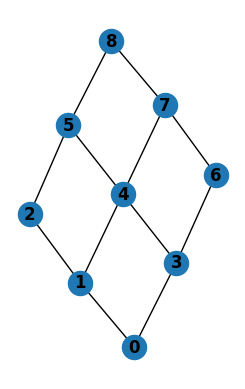

In [33]:
subax1 = plt.subplot(121)
nx.draw(puzzle, with_labels=True, font_weight='bold')

Next, a quick utility class which will tell us what moves we can make with our puzzle given our blank location, and distances between various tiles.

In [34]:
class PuzzleManipulator:
  def __init__(self, puzzle):
    self.puzzle = puzzle
    self.distances = dict(nx.all_pairs_shortest_path(puzzle))

  def available_moves(self, blank_node):
    moves = list(self.puzzle.adj[blank_node].keys())
    return moves

  def manhatten_distance(self, node1, node2):
    return len(self.distances[node1][node2])

In [35]:
puzzle_manipulator = PuzzleManipulator(puzzle)

puzzle_manipulator.available_moves(4)

[1, 3, 5, 7]

## Solving the puzzle

We have many options for solving this puzzle. Some are called *uninformed approaches* and simply aim to explore the search space systematically to find a solution. Other approaches are *informed approaches* in that they try to use knowledge about the search space and the goal state to search the space more efficiently.

### Breadth-first Search

Breadth-first search (BFS) is an uninformed approach. It simply makes every possible choice in order.

Imagine our blank is occupying node 0, and our full initial puzzle state as state **a**. Our choices are to swap the blank with node 1 and node 3. BFS would perform these choices and add them to the *frontier*, the space of the decision tree being explored. So the frontier consists of the puzzle in which node 0 and 1 have been swapped, and the puzzle in which node 0 and 3 have been swapped. Lets call these states **b** and **c**.


```
frontier = [a]
new_states = expand(frontier.pop(0))
frontier.extend(new_states)
# frontier now equals [b, c]
```

The next item in the frontier would then the puzzle in which node 0 and 1 have been swapped, a.k.a in where the blank resides at node 1. So, the available moves are to perform swaps from node 1 to nodes 0, 2, and 4. However, since a swap to node 0 would simply create the initial puzzle *again*, we do not have to consider this choice. So, we would create two states in which we have swapped node 1 for node 2 and 4, creating states **d** and **e**.
```
frontier = [b, c]
new_states = expand(frontier.pop(0))
frontier.extend(new_states)
# frontier now equals [c, d, e]
```

So, BFS is essentially an expansion operation using a FIFO queue. Lets implement this in code.

In [36]:
class Node:

  def __init__(self, state, puzzle_manipulator, parent):
    self.state = state
    self.puzzle_manipulator = puzzle_manipulator
    self.parent = parent
    if parent:
      self.depth = parent.depth + 1
    else:
      self.depth = 0

  def expand(self):
    blank_node = self.state.index(None)
    moves = self.puzzle_manipulator.available_moves(blank_node)
    new_states = []
    for move in moves:
      new_state = self.state.copy()
      new_state[blank_node] = new_state[move]
      new_state[move] = None
      new_states.append(new_state)
    return [Node(state, self.puzzle_manipulator, self) for state in new_states]

In [37]:
class BFS:
  def __init__(self, puzzle_manipulator):
    self.puzzle_manipulator = puzzle_manipulator

  def search(self, initial_state, goal_state):
    initial_node = Node(initial_state, self.puzzle_manipulator, None)
    if initial_node.state == goal_state:
      return initial_node
    frontier = [initial_node]
    reached = {tuple(initial_state)}
    ticker = 1
    while frontier:
      node = frontier.pop(0)
      child_nodes = node.expand()
      for child_node in child_nodes:
        if child_node.state == goal_state:
          return child_node
        if (hashed_state := tuple(child_node.state)) not in reached:
          reached.add(hashed_state)
          frontier.append(child_node)
    return None


In [38]:
def get_solution_path(solution):
  path = []
  node = solution
  while node is not None:
    path.append(node.state)
    node = node.parent
  return path[::-1]

In [39]:
bfs = BFS(puzzle_manipulator)
solution = bfs.search(initial_state, goal_order)
if solution:
  solution_path = get_solution_path(solution)
  print(len(solution_path))
  print(solution_path)
else:
  print("No solution found")

27
[[3, 6, 7, 4, None, 2, 5, 0, 1], [3, None, 7, 4, 6, 2, 5, 0, 1], [None, 3, 7, 4, 6, 2, 5, 0, 1], [4, 3, 7, None, 6, 2, 5, 0, 1], [4, 3, 7, 6, None, 2, 5, 0, 1], [4, 3, 7, 6, 0, 2, 5, None, 1], [4, 3, 7, 6, 0, 2, None, 5, 1], [4, 3, 7, None, 0, 2, 6, 5, 1], [4, 3, 7, 0, None, 2, 6, 5, 1], [4, None, 7, 0, 3, 2, 6, 5, 1], [None, 4, 7, 0, 3, 2, 6, 5, 1], [0, 4, 7, None, 3, 2, 6, 5, 1], [0, 4, 7, 3, None, 2, 6, 5, 1], [0, 4, 7, 3, 2, None, 6, 5, 1], [0, 4, None, 3, 2, 7, 6, 5, 1], [0, None, 4, 3, 2, 7, 6, 5, 1], [0, 2, 4, 3, None, 7, 6, 5, 1], [0, 2, 4, 3, 7, None, 6, 5, 1], [0, 2, 4, 3, 7, 1, 6, 5, None], [0, 2, 4, 3, 7, 1, 6, None, 5], [0, 2, 4, 3, None, 1, 6, 7, 5], [0, 2, 4, 3, 1, None, 6, 7, 5], [0, 2, None, 3, 1, 4, 6, 7, 5], [0, None, 2, 3, 1, 4, 6, 7, 5], [0, 1, 2, 3, None, 4, 6, 7, 5], [0, 1, 2, 3, 4, None, 6, 7, 5], [0, 1, 2, 3, 4, 5, 6, 7, None]]


### Complications of BFS

BFS has benefits and drawbacks. While it is a complete search algorithm in that it will explore the entire search space, it is non-optimal in that it must store every state it has seen. In this problem we have 9! (362880) potential states, which is not a huge problem. However, imagine we scale up to a 4x4 grid variant of 3x3, in which there are 16 nodes and therefore 16! (20,922,789,888,000). This is a much larger potential search space, and storing each of these states will eat up a significant chunk of memory

In [40]:
initial_state_15_problem = [4, 0, 6, 1, 9, 12, 13, 3, 8, 5, 2, 7, 11, None, 14, 10]
goal_order_15_problem = list(range(15)) + [None]

print(f"Initial state: {initial_state_15_problem}")
print(f"Goal state: {goal_order_15_problem}")

Initial state: [4, 0, 6, 1, 9, 12, 13, 3, 8, 5, 2, 7, 11, None, 14, 10]
Goal state: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, None]


In [41]:
fifteen_puzzle = nx.Graph()

fifteen_puzzle.add_edges_from(
    [
        (0, 1), (0, 4),
        (1, 2), (1, 5),
        (2, 3), (2, 6),
        (3, 7),
        (4, 5), (4, 8),
        (5, 6), (5, 9),
        (6, 7), (6, 10),
        (7, 11),
        (8, 9), (8, 12),
        (9, 10), (9, 13),
        (10, 11), (10, 14),
        (11, 15),
        (12, 13),
        (13, 14),
        (14, 15)
    ]
)

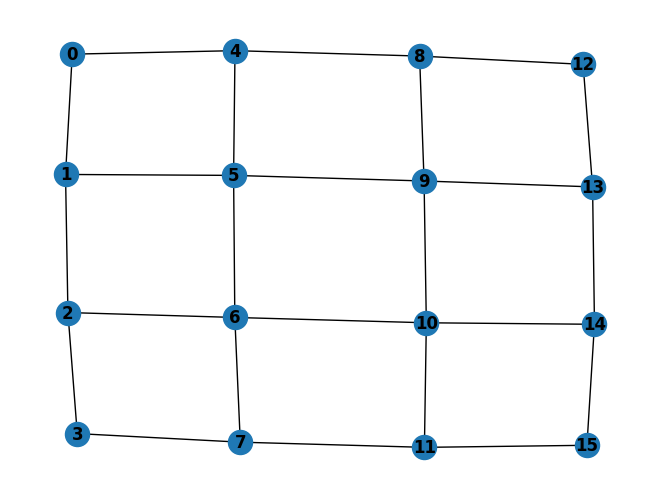

In [42]:
nx.draw(fifteen_puzzle, with_labels=True, font_weight='bold')

In [43]:
fifteen_puzzle_manipulator = PuzzleManipulator(fifteen_puzzle)
fifteen_puzzle_manipulator.available_moves(5)

[1, 4, 6, 9]

Uncomment and run the below however long you like. Unless you're very patient, you'll see its not finding the solution anytime soon.

In [44]:
# fifteen_bfs = BFS(fifteen_puzzle_manipulator)
# solution_fifteen = fifteen_bfs.search(initial_state_15_problem, goal_order_15_problem)
# if solution:
#   solution_path = get_solution_path(solution_fifteen)
#   print(len(solution_path))
#   print(solution_path)
# else:
#   print("No solution found")

We clearly need to use a different way to solve this puzzle. Enter A*.

### A* search

A\* search uses information about the goal state and search space to search the environment in a more selective way, and is therefore an *informed* search approach. Specifically, A\* relies on heuristics which guess at how far away the solution is from any given state. In this case, the state with the lowest expected distance from the solution gets explored first.

What heuristic shall we use? A good one here is the summed Manhatten distance for each tile. Manhatten distance means the distance from each tile with its goal location where the distance is calculated as the number of adjacent tiles.

Some examples:

In the fifteen-problem network above, imagine a tile is at node 0 which has its goal as node 5. The Manhatten distance is one vertical movement and one horizontal movement (0 -> 4 -> 5 or 0 -> 1 -> 5), yielding a score of 2.

The *summed* Manhatten distance over the whole structure means the Manhatten distance for each tile and its goal node.

**NB** I already implemented the distance function in the PuzzleManipulator class above, where we can use the inbuilt functionality of `networkx` to calculate the shortest paths for us.

In [45]:
class AStarSearch:
  def __init__(self, puzzle_manipulator):
    self.puzzle_manipulator = puzzle_manipulator
    self.ticker = 1

  def _score_state(self, node):
    return self._calculate_manhatten_distance(node.state) + node.depth

  def _calculate_manhatten_distance(self, state):
    """
    Each tile in the state represents where it wants to be.
    Take the below state:

    [4, 0, 6, 1, 9, 12, 13, 3, 8, 5, 2, 7, 11, None, 14, 10]

    The zeroth element is the tile at node 0. Its number means it wants to be at
    node 4. So we calculate the Manhatten distance between node 0 and 4 for
    this element.

    NB: I assume the blank always belongs at the last node.
    """
    score = 0
    for current_node, goal_node in enumerate(state):
      if goal_node is None:

        score += self.puzzle_manipulator.manhatten_distance(current_node, len(state) - 1)
      else:
        score += self.puzzle_manipulator.manhatten_distance(current_node, goal_node)
    return score

  def search(self, initial_state, goal_state):
    initial_node = Node(initial_state, self.puzzle_manipulator, None)
    initial_score = self._score_state(initial_node)

    frontier = [(initial_node, initial_score)]
    reached = set()

    while frontier:

      frontier = sorted(frontier, key=lambda x: x[1])
      node, distance = frontier.pop(0)

      if tuple(node.state) in reached:
        continue
      else:
        reached.add(tuple(node.state))

      if node.state == goal_state:
        return node

      child_nodes = node.expand()
      for child_node in child_nodes:
        score = self._score_state(child_node)
        frontier.append((child_node, score))

    return None


In [46]:
a_star_search = AStarSearch(fifteen_puzzle_manipulator)
solution = a_star_search.search(initial_state_15_problem, goal_order_15_problem)
if solution:
  solution_path = get_solution_path(solution)
  print(len(solution_path))
else:
  print("No solution found")

33


This process completes in 37 seconds on a Google Colab CPU. The impact of using guided search has had a huge uplift in finding our solution. Furthermore, because the heuristic we're using is *admissible* -- a technical search term meaning we never overestimates the cost of the path leading to the goal -- we are still guaranteed to find the optimal path to the solution using this method.

We could further optimise this path-finding by implementing further ways to constrain search, for example, *beam search*. In beam search we explicitly limit the size of the frontier to explore.

Here's a re-implementation of the above code with a beam variable added to the search function.

In [47]:
class BeamAStarSearch(AStarSearch):
  def search(self, initial_state, goal_state, beam_size):
    initial_node = Node(initial_state, self.puzzle_manipulator, None)
    initial_score = self._score_state(initial_node)

    frontier = [(initial_node, initial_score)]
    reached = set()

    while frontier:
      frontier = sorted(frontier, key=lambda x: x[1])
      frontier = frontier[:beam_size] # THIS IS THE ONLY CHANGED LINE
      node, distance = frontier.pop(0)

      if tuple(node.state) in reached:
        continue
      else:
        reached.add(tuple(node.state))

      if node.state == goal_state:
        return node

      child_nodes = node.expand()
      for child_node in child_nodes:
        score = self._score_state(child_node)
        frontier.append((child_node, score))

    return None


In [48]:
a_star_search = BeamAStarSearch(fifteen_puzzle_manipulator)
solution = a_star_search.search(initial_state_15_problem, goal_order_15_problem, beam_size=15)
if solution:
  solution_path = get_solution_path(solution)
  print(len(solution_path))
else:
  print("No solution found")

419


Our speed has gone massively up, however our solution is obviously non-optimal. Increasing the size of the beam to make a trade-off between efficiency and optimality is a matter of experimentation and preference. Let's widen the beam to 500.

In [49]:
solution = a_star_search.search(initial_state_15_problem, goal_order_15_problem, beam_size=1000)
if solution:
  solution_path = get_solution_path(solution)
  print(len(solution_path))
else:
  print("No solution found")

51


Our solution is clearly still non-optimal, however for a solution that is less than twice as long as the original solution we only do 10% of the computation.

There are many other ways to speed up computation, some preserving optimality, others not. For example, we might compute the solutions to subproblems of the puzzle, only considering a subset of the tiles and their intended solution at a time. By doing this in a sophisticated way, using disjoint pattern databases, one can get a much better heuristic than manhatten distance and achieve huge speedups.

For the moment, I leave this work to readers.

Thank you for following on!